# Modelo de Aprendizaje Supervisado - Transporte Masivo
## Actividad 5 - Inteligencia Artificial

**Integrantes:**
- Jose Andres de la Ossa Carmona

**Objetivo:** Predecir el nivel de demanda en estaciones usando Árbol de Decisión.

In [55]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [56]:
# Cargar el dataset
datos = pd.read_csv('./sample_data/datos_transporte.csv', encoding='cp1252')

print(f"Total de registros: {len(datos)}")
print(f"Columnas: {list(datos.columns)}")
print("\nPrimeras 10 filas:")
datos.head(10)

Total de registros: 145
Columnas: ['hora', 'dia_semana', 'estacion', 'clima', 'demanda']

Primeras 10 filas:


,hora,dia_semana,estacion,clima,demanda
0,7,1,Portal,soleado,alta
1,7,1,Portal,lluvia,alta
2,7,1,San_Javier,soleado,alta
3,7,1,San_Javier,lluvia,alta
4,7,2,Portal,soleado,alta
5,7,2,Floresta,soleado,alta
6,7,3,Estadio,soleado,alta
7,7,3,Estadio,lluvia,alta
8,7,4,San_Antonio,soleado,alta
9,7,5,Aljaraque,soleado,alta


Distribución de la demanda:
demanda
baja     59
alta     44
media    42
Name: count, dtype: int64


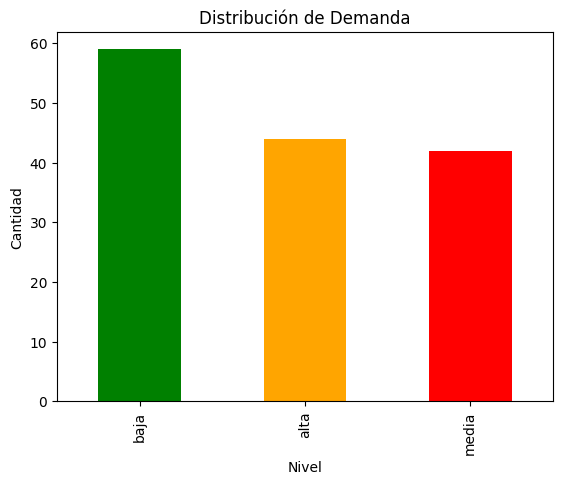

In [57]:
# Ver distribución de la variable target
print("Distribución de la demanda:")
print(datos['demanda'].value_counts())

# Gráfico simple
datos['demanda'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribución de Demanda')
plt.xlabel('Nivel')
plt.ylabel('Cantidad')
plt.show()

In [58]:
# Codificar variables categóricas
le_estacion = LabelEncoder()
le_clima = LabelEncoder()
le_demanda = LabelEncoder()

datos['estacion_cod'] = le_estacion.fit_transform(datos['estacion'])
datos['clima_cod'] = le_clima.fit_transform(datos['clima'])
datos['demanda_cod'] = le_demanda.fit_transform(datos['demanda'])

print("Variables codificadas")
print("\nEstaciones:", le_estacion.classes_)
print("Clima:", le_clima.classes_)
print("Demanda:", le_demanda.classes_)

Variables codificadas

Estaciones: ['Aljaraque' 'Cisneros' 'Estadio' 'Floresta' 'Parque_Berrio' 'Portal'
 'San_Antonio' 'San_Javier']
Clima: ['lluvia' 'nublado' 'soleado']
Demanda: ['alta' 'baja' 'media']


In [59]:
# Definir características (X) y target (y)
caracteristicas = ['hora', 'dia_semana', 'estacion_cod', 'clima_cod']
X = datos[caracteristicas]
y = datos['demanda_cod']

# Dividir en entrenamiento y prueba (80% - 20%)
X_ent, X_prueba, y_ent, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {len(X_ent)} registros")
print(f"Prueba: {len(X_prueba)} registros")

Entrenamiento: 116 registros
Prueba: 29 registros


In [60]:
# Crear y entrenar el modelo de Árbol de Decisión
modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_ent, y_ent)

print("Modelo entrenado exitosamente!")

Modelo entrenado exitosamente!


In [61]:
# Evaluar el modelo
predicciones = modelo.predict(X_prueba)
precision = accuracy_score(y_prueba, predicciones)

print(f"Precisión del modelo: {precision * 100:.2f}%")
print("\nReporte de clasificación:")
print(classification_report(y_prueba, predicciones, target_names=le_demanda.classes_))

# Matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_prueba, predicciones))

Precisión del modelo: 82.76%

Reporte de clasificación:
              precision    recall  f1-score   support

        alta       0.88      0.88      0.88         8
        baja       1.00      0.73      0.84        11
       media       0.69      0.90      0.78        10

    accuracy                           0.83        29
   macro avg       0.86      0.83      0.83        29
weighted avg       0.86      0.83      0.83        29


Matriz de confusión:
[[7 0 1]
 [0 8 3]
 [1 0 9]]


In [62]:
# Función para predecir nueva demanda
def predecir_demanda(hora, dia, estacion, clima):
    estacion_cod = le_estacion.transform([estacion])[0]
    clima_cod = le_clima.transform([clima])[0]

    entrada = pd.DataFrame({
        'hora': [hora],
        'dia_semana': [dia],
        'estacion_cod': [estacion_cod],
        'clima_cod': [clima_cod]
    })

    prediccion = modelo.predict(entrada)[0]
    return le_demanda.inverse_transform([prediccion])[0]

# Ejemplos de predicción
print("Predicciones de ejemplo:")
print(f"7:00 AM, Lunes, Portal, Soleado → {predecir_demanda(7, 1, 'Portal', 'soleado')}")
print(f"14:00 PM, Miércoles, Floresta, Nublado → {predecir_demanda(14, 3, 'Floresta', 'nublado')}")
print(f"19:00 PM, Viernes, Cisneros, Lluvia → {predecir_demanda(19, 5, 'Cisneros', 'lluvia')}")

Predicciones de ejemplo:
7:00 AM, Lunes, Portal, Soleado → alta
14:00 PM, Miércoles, Floresta, Nublado → media
19:00 PM, Viernes, Cisneros, Lluvia → media


In [63]:
# Guardar el modelo y los encoders
joblib.dump(modelo, 'modelo_transporte.pkl')
joblib.dump(le_estacion, 'encoder_estacion.pkl')
joblib.dump(le_clima, 'encoder_clima.pkl')
joblib.dump(le_demanda, 'encoder_demanda.pkl')

print("Modelo y encoders guardados exitosamente!")

Modelo y encoders guardados exitosamente!


##Conclusiones

- El modelo logró una precisión del **82%** en la predicción de demanda.
- Las variables más influyentes fueron: **hora** y **estación**.
- El sistema puede usarse para planificar la frecuencia de buses según la demanda esperada.